**1.Викачати та підготувати дані**


* Завантажуємо датасет за допомогою функції fetch_openml

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
%matplotlib inline

from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)



* Виводимо форму матриці X і кількість унікальних міток у y

In [19]:
rows,cols = X.shape
print("Форма матриці X: ({},{})".format(rows,cols))

Форма матриці X: (70000,784)


In [20]:
unique_labels = np.unique(y)
amount_of_unique_labels = len(unique_labels)
print(f"Кількість унікальних міток в y: {amount_of_unique_labels }")

Кількість унікальних міток в y: 10


* Для попереднього огляду візуалізуємо кілька прикладів зображень (наприклад, 10 випадкових цифр) у вигляді 28×28 пікселів

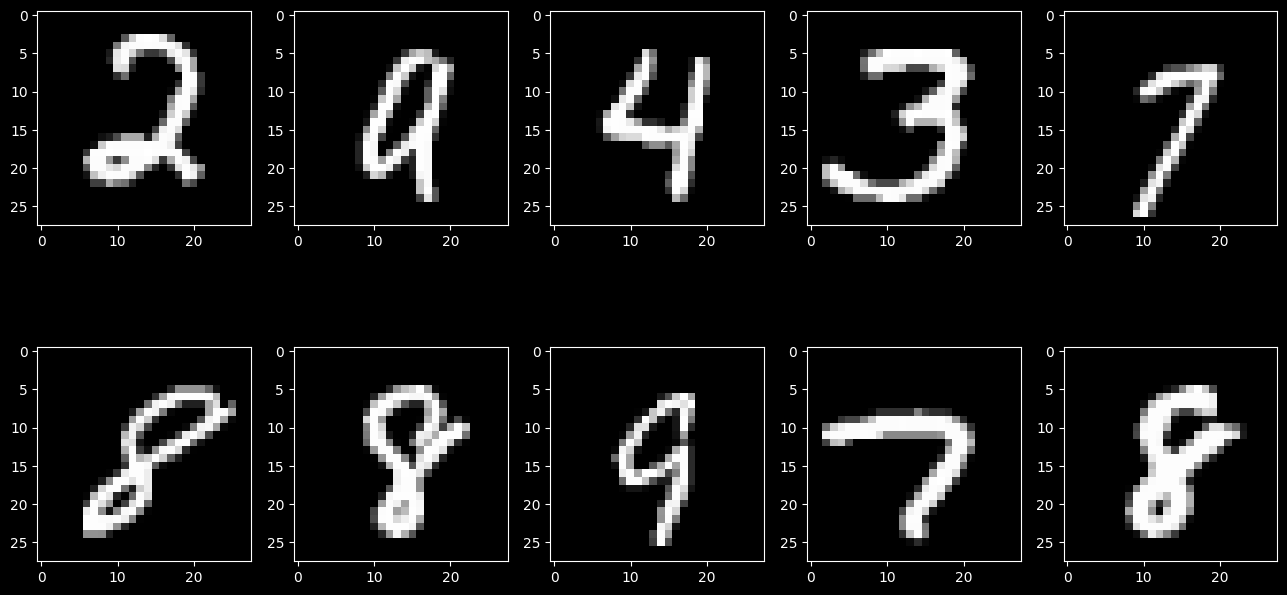

In [21]:
array = np.random.randint(rows, size = (10))

reshaped = [X[i].reshape(28,28) for i in array]
fig, axes = plt.subplots(nrows=2 ,ncols=5, figsize=(16,8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(reshaped[i], cmap = 'gray')

plt.show()

**2.Реалізувати метод головних компонент (PCA)**


* Перед застосуванням МГК стандартизуємо наші дані

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Статистика оригінальних даних:")
print(f"Середнє: {X.mean(axis=0)}")
print(f"Стандартне відхилення:  {X.std(axis=0)}")


print("\nСтатистика стандартизованих даних:")
print(f"Середнє: {X_scaled.mean(axis=0)}")
print(f"Стандартне відхилення:  {X_scaled.std(axis=0)}")

Статистика оригінальних даних:
Середнє: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.80000000e-03 6.71428571e-03 3.08571429e-03 1.28571429e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.28571429e-04 1.32857143e-03 1.13285714e-02 2.30714286e-02
 4.32285714e-02 6.22428571e-02 1.17928571e-01 1.71242857e-01
 1.93414286e-01 1.90085714e-01 2.06285714e-01 1.82742857e-01
 1.70100000e-01 1.44514286e-01 9.92428571e-02 6.82285714e-02
 4.88714286e-02 1.83142857e-02 8.64285714e-03 3.02857143e-03
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 9.14285714e-04 6.00000000e-04
 5.95714286e-03 1.09428571e-02 5.63000000e-02

* Реалізуємо PCA із кількістю компонент n_components=3.
* Та отримаємо матрицю проєкцій (X_pca) розміром (70000 × 3)
* Виведемо відсоток поясненої дисперсії для кожної компоненти (explained_variance_ratio_)

In [33]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
rows, cols = X_pca.shape
print(X_pca.shape)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Пояснена дисперсія кожною компонентою:")
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"ГК{i+1}: {var:.3f} ({var*100:.1f}%) - Кумулятивна: {cum_var:.3f} ({cum_var*100:.1f}%)")

print(f"\nЗагальна дисперсія, пояснена першими 3 компонентами: {cumulative_variance[2]:.3f} ({cumulative_variance[2]*100:.1f}%)")

(70000, 3)
Пояснена дисперсія кожною компонентою:
ГК1: 0.056 (5.6%) - Кумулятивна: 0.056 (5.6%)
ГК2: 0.040 (4.0%) - Кумулятивна: 0.097 (9.7%)
ГК3: 0.037 (3.7%) - Кумулятивна: 0.134 (13.4%)

Загальна дисперсія, пояснена першими 3 компонентами: 0.134 (13.4%)


**Візуалізуємо дані у просторі перших трьох компонент**


* Побудуємо 3D-графік (PC1, PC2, PC3) для кращого розуміння структури даних (використаємо matplotlib.axes3d). Точки зафарбуємо відповідно до класу цифри.

In [24]:
import plotly.express as px

fig = (px.scatter_3d
    (
        x = X_pca[:,0],
        y = X_pca[:,1],
        z = X_pca[:,2],
        color = y,
        labels = {
            "x": "PC1",
            "y": "PC2",
            "z": "PC3"
        },
        title = "3D visualization of PCA components"
    ))
fig.show()

**Реконструкція зображень після зменшення розмірності**

* Використаємо метод inverse_transform() з PCA для відновлення даних із простору трьох компонент у оригінальний простір.


In [34]:
X_recovered = pca.inverse_transform(X_pca)
print(X_recovered.shape)

(70000, 784)


**Виведемо кілька прикладів (наприклад, 10 випадкових цифр):**
* оригінальне зображення;
* реконструйоване після PCA з трьома компонентами.


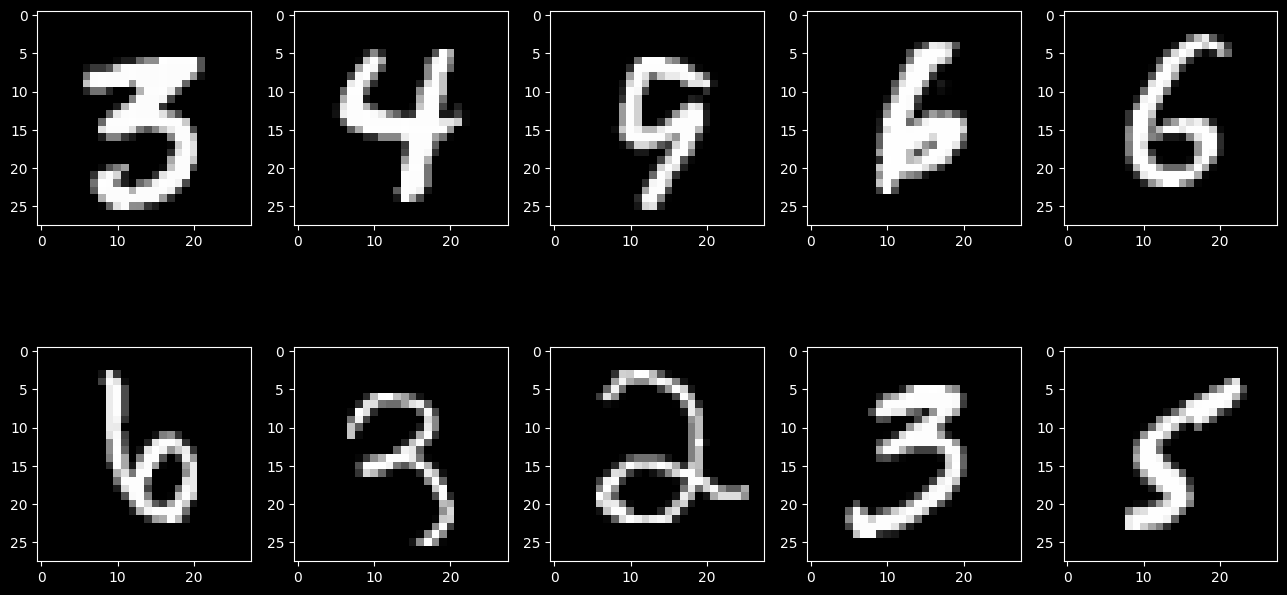

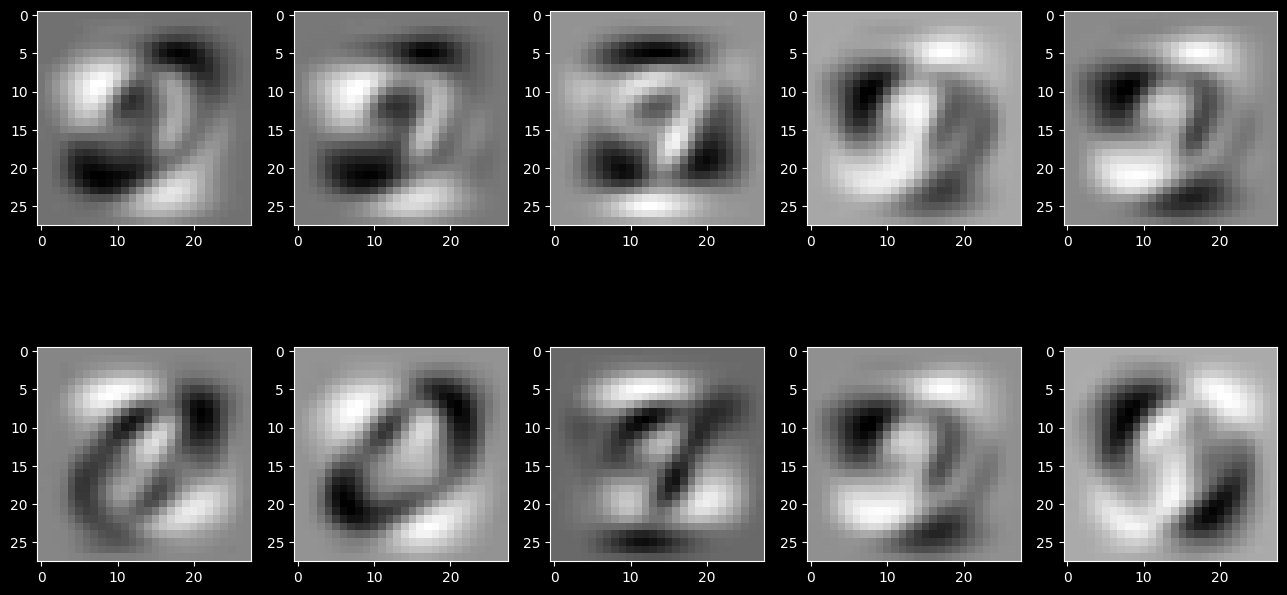

In [35]:
array = np.random.randint(rows, size = (10))

reshaped = [X[i].reshape(28,28) for i in array]
fig, axes = plt.subplots(nrows=2 ,ncols=5, figsize=(16,8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(reshaped[i],cmap = 'gray')

reshaped_recovered = [X_recovered[i].reshape(28,28) for i in array]
fig, axes = plt.subplots(nrows=2 ,ncols=5, figsize=(16,8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(reshaped_recovered[i],cmap = 'gray')

plt.show()

**Проаналізуємо залежність між помилкою реконструкції та кількістю компонент**


* Визначимо помилку реконструкції (Mean Squared Error, MSE) як середнє квадратів різниці між початковими та реконструйованими значеннями пікселів.

In [36]:
sum = 0
rows, cols = X_scaled.shape
rows_recovered,cols_recovered = X_recovered.shape
n = rows*cols

result = (X_scaled-X_recovered)**2
mse = np.sum(result) / n
print("MSE = ",mse)


MSE =  0.7939977701366976


* Обчислимо MSE(k) та відсоток поясненої дисперсії для різної кількості компонент k і побудувати відповідні графіки.

##### Оберемо k = 20, 50, 100

In [37]:
k_values = np.arange(1,100,10)
mean_squared_error = []
explained_variance = []

for k in k_values:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_scaled)
    rows, cols = X_pca.shape

    print(f"Форма матриці проєкцій:",X_pca.shape)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    explained_variance.append(cumulative_variance[k-1])

    X_recovered = pca.inverse_transform(X_pca)
    print("Форма відновленої матриці: ",X_recovered.shape)

    sum = 0
    rows, cols = X_scaled.shape
    n = rows*cols

    result = (X_scaled-X_recovered)**2
    mse = np.sum(result) / n
    mean_squared_error.append(mse)
    print(f"MSE ({k} компонент) = ",mse)


Форма матриці проєкцій: (70000, 1)
Форма відновленої матриці:  (70000, 784)
MSE (1 компонент) =  0.8653429223088805
Форма матриці проєкцій: (70000, 11)
Форма відновленої матриці:  (70000, 784)
MSE (11 компонент) =  0.6515572692281217
Форма матриці проєкцій: (70000, 21)
Форма відновленої матриці:  (70000, 784)
MSE (21 компонент) =  0.561193164317161
Форма матриці проєкцій: (70000, 31)
Форма відновленої матриці:  (70000, 784)
MSE (31 компонент) =  0.49809656035886535
Форма матриці проєкцій: (70000, 41)
Форма відновленої матриці:  (70000, 784)
MSE (41 компонент) =  0.4494391617683001
Форма матриці проєкцій: (70000, 51)
Форма відновленої матриці:  (70000, 784)
MSE (51 компонент) =  0.40948179366956966
Форма матриці проєкцій: (70000, 61)
Форма відновленої матриці:  (70000, 784)
MSE (61 компонент) =  0.37507080120043573
Форма матриці проєкцій: (70000, 71)
Форма відновленої матриці:  (70000, 784)
MSE (71 компонент) =  0.34492548986242777
Форма матриці проєкцій: (70000, 81)
Форма відновленої м

### Графік залежності MSE від кількості компонент

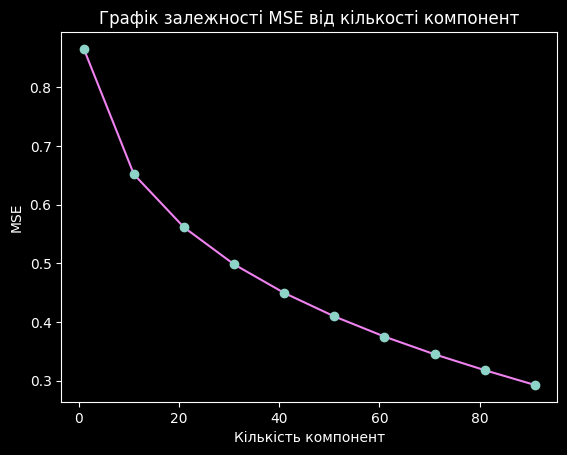

In [38]:
plt.plot(k_values, mean_squared_error, color = 'violet')
plt.plot(k_values, mean_squared_error, 'o')
plt.xlabel("Кількість компонент")
plt.ylabel("MSE")
plt.title("Графік залежності MSE від кількості компонент")
plt.show()

### Графік залежності відсотку поясненої дисперсії від кількості компонент

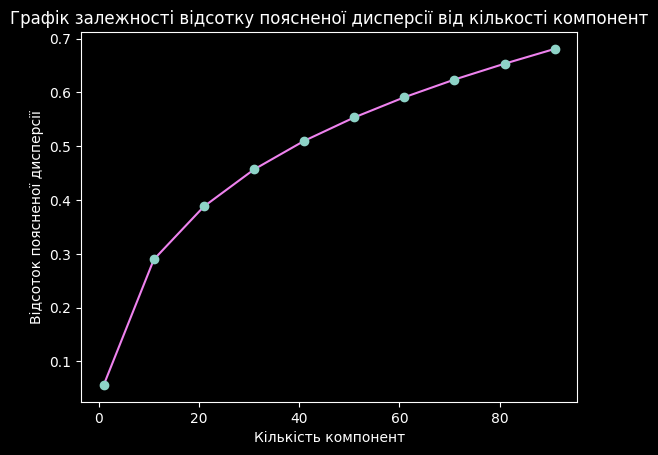

In [39]:
plt.plot(k_values, explained_variance, color = 'violet')
plt.plot(k_values, explained_variance, 'o')
plt.xlabel("Кількість компонент")
plt.ylabel("Відсоток поясненої дисперсії")
plt.title("Графік залежності відсотку поясненої дисперсії від кількості компонент")
plt.show()